<img src="../common/images/logo/selene-logo-640.png" style="max-height:75px;" alt="SELENE Logo" />

**Disclaimer:** This Jupyter Notebook contains content generated with the assistance of AI. While every effort has been made to review and validate the outputs, users should independently verify critical information before relying on it. The SELENE notebook repository is constantly evolving. We recommend downloading or pulling the latest version of this notebook from Github.

# Gradient Descent &mdash; The (Very) Basics

Gradient Descent is an iterative optimization algorithm used to find the minimum of a function by repeatedly taking steps in the direction of the steepest decrease of that function. In the context of machine learning, this function is typically a **loss function** that measures how well a model's predictions match the data. By computing the gradient of the loss with respect to the model parameters, Gradient Descent tells us *how* and *in which direction* to adjust those parameters to reduce error. Conceptually, it can be thought of as navigating a landscape of error values, moving downhill step by step until a (local) minimum is reached.

The general purpose of Gradient Descent is therefore **parameter optimization**. Most machine learning models (from linear regression to deep neural networks) are defined by a set of parameters (weights and biases) that determine their behavior. These parameters are not chosen analytically in closed form for complex models; instead, they are learned from data. Gradient Descent provides a systematic, scalable way to tune millions (or even billions) of parameters by relying only on local information: the gradient at the current point.

Gradient Descent has become a cornerstone of machine learning and neural networks because it scales extremely well to high-dimensional problems and works hand-in-hand with **backpropagation**. Backpropagation efficiently computes gradients of the loss with respect to all parameters in a neural network, and Gradient Descent uses those gradients to update the parameters. This separation of concerns &mdash; gradient computation on one side, optimization on the other &mdash; makes the training of deep models both conceptually clean and computationally feasible.

We need Gradient Descent because, for most realistic models, there is no direct mathematical solution for finding the optimal parameters. The loss surfaces of neural networks are highly non-linear, high-dimensional, and often non-convex. Gradient Descent offers a practical and flexible approach to navigating these complex landscapes, allowing models to improve gradually through incremental updates. Understanding Gradient Descent at a fundamental level is therefore essential: it reveals *how* learning actually happens inside a model and provides the foundation for more advanced optimization methods used in modern machine learning.


### Setting up the Notebook

#### Make Required Imports

This notebook requires the import of different Python packages but also additional Python modules that are part of the repository. If a package is missing, use your preferred package manager (e.g., [conda](https://anaconda.org/anaconda/conda) or [pip](https://pypi.org/project/pip/)) to install it. If the code cell below runs with any errors, all required packages and modules have successfully been imported.

In [1]:
import sys
sys.path.insert(0, '../common')

from src.utils.plotting.gd import *

#### Preliminaries

* This notebook assumes a basic understanding of calculus and concepts of derivatives and partial derivatives.
* For the examples and explanations, we assume general function and not specific loss function used for training machine learning models. At the and, we briefly motivate how loss functions add a certain complexity to idea of Gradient Descent.

---

## Motivation

Find critical points such as minima, maxima, or saddle points of a function might be familiar to you from your calculus classes. So it might not be obvious why we need methods such as Gradient Descent in the first place &mdash; assuming that you found critical points without it in your classes. We should therefore first clarify why we need the Gradient Descent algorithm and provide its basic intuition before delving deeper into its inner workings.

### Why do we need Gradient Descent?

To motivate the algorithm, let's assume we have a very simply function $f(x)$ which is defined as:

$$\large
f(x) = x^2 - 4x + 5
$$

We can also define this function as a Python method:

In [2]:
def f1(x):
    return x**2 - 4*x + 5

Before we continue, we should first have a quick look at the function; for this, we provide the auxiliary method `plot_function()`.

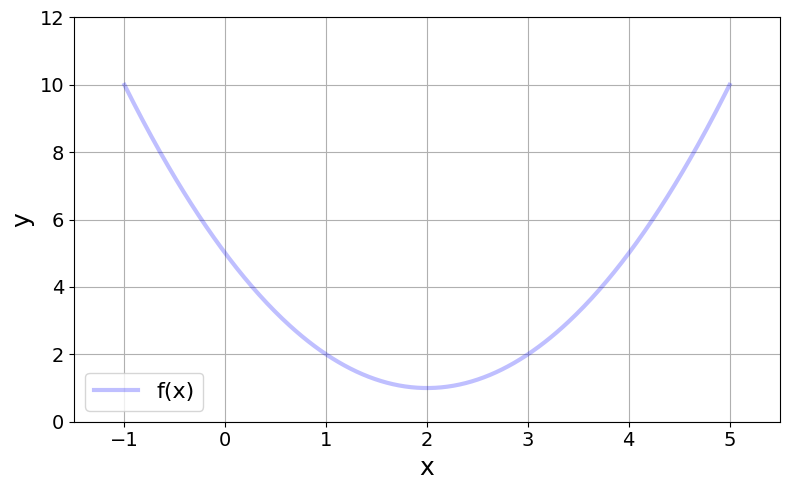

In [3]:
plot_function(f1)

If we now assume that $f(x)$ is some kind of loss function where we want to find the value for $x$ that minimizes this function. Of course, given the simple nature of $f(x)$ and just by looking at the plot above, we can see that $x=2$ minimizes $f(x)$ with $f(2) = 1$. Beyond eye-balling the solution, the systematic approach to find the minimum is using calculus by means of the first derivative $\frac{df}{dx}$. If $g(x)$ denotes the first derivative of $f(x)$, and using the derivation rules from calculus, we get:

$$\large
g(x) = \frac{df(x)}{dx} = 2x - 4
$$

The first derivative tells us the **rate of change** of a function with respect to its input, including both the direction** and the steepness of that change. Its sign indicates whether the function is increasing or decreasing, and points where it is zero identify **critical points** where the behavior of the function may change. Thus, to find $x$ that minimizes $f(x)$, we need to find $x$ where $g(x) = 0$. Again, given the very simple nature of $f(x)$ and thus $g(x)$, this is a very simple calculation.

$$
\begin{align}
\large 2x - 4\ &\large= 0\\[0.25em]
\large 2x\ &\large= 4\\[0.25em]
\large x\ &\large= 2
\end{align}
$$

Of course, we get the result that $x=2$ minimizes $f(x)$ as we spotted from the plot.

**Important:** The first derivative of a function allows us to identify critical points, where the slope is zero and the function has a horizontal tangent. These points are candidates for **local minima, local maxima, or saddle points**. However, the first derivative alone does not tell us which type of point we have found. To classify a critical point, we must perform an additional check &mdash; either by examining the second derivative (which reveals local curvature) or by evaluating the function slightly before and after the point to see whether the function value decreases, increases, or does both. In the context of **loss functions**, we typically do not need to explicitly distinguish between minima, maxima, and saddle points. This is because training is formulated as a **pure minimization problem**: we only ever move parameters in the direction that reduces the loss. Gradient-based optimization methods like Gradient Descent naturally move *away* from maxima and tend not to get stuck at saddle points in practice, especially in high-dimensional spaces where true saddle points are unstable. As a result, it is sufficient to follow the gradient and monitor whether the loss decreases, rather than classifying each stationary point mathematically.

Now that we have seen an example for how we can find the minimum of a function, you may wonder what the big deal is, and why we cannot train machine learning models &mdash; not even Linear Regression let alone large neural networks &mdash; that way. Our example was easy to solve because $g(x)$, i.e., the derivative of $f(x)$, was such a simple function that allowed us to set $g(x) = 0$ and solve for $x$. In other words, we could find an analytical solution in terms of a closed-form expression that allowed us to find $x$ that minimized $f(x)$ directly.

However, if $f(x)$ and particularly its first derivative, becomes more complex, this might no longer be possible. While we can still compute the derivative, and set the derivative to $0$, we fail to solve for $x$.

$$
\begin{align}
\large g(x)\ &\large = 0\\[0.25em]
\large\Downarrow\\[0.25em]
\large x\ &\large = {\color{red} \times} \\
\end{align}
$$

For most machine learning models (but especially neural networks), the loss function is highly non-linear, high-dimensional, and has millions of parameters, making such equations impossible to solve in closed form. In fact, even basic Logistic Regression &mdash; which can crudely be considered a neural network with a single neuron &mdash; cannot be solved analytically. Additionally, real-world loss function are often **non-convex**, with many local minima and saddle points. Even if we could write down the equations, solving them exactly would be computationally intractable.

### Basic Idea & Intuition

Even if $g(x)$ is too complex to set to $0$ and solve for $x$, it can still give useful insights to find the value for $x$ that minimizes $f(x)$. Recall that the first derivative of a function (here $g(x) = \frac{df(x)}{x}$) allows us to compute the slope (i.e., the **gradient**) of function $f(x)$ for any value of $x$. For example, if we want to know the slope or gradient for $x=0$, we get $g(0) = 2\cdot0-4=-4$. To visualize this, let's first define a method `df1` that computes the gradient, where `df` stands for the derivative $df(x)$ (or just $df$), and we use the number since we will define more methods throughout the notebook.

In [4]:
def df1(x):
    return 2*x - 4

Naturally, `df1` simply implements the formula for computing the gradient as shown above. To plot the gradient, we provide the method `animate_gradient()` that computes the gradient of $f(x)$ for different values of $x$ in the form of simple animation; just run the code cell below to create and play the animation.

In [5]:
animate_gradient(f1, df1, x_start=-1, x_end=5, step=0.5)

We can also plot a single frame of the animation by using the `show_step` argument. In the code cell below, we change the previous method call by setting `show_step=2` which refers to the step/frame where $x=0$. You can change the value of `show_step` to see the gradient for different values of `x`, but the subsequent discussion assumes that we consider the gradient at $x=0$.

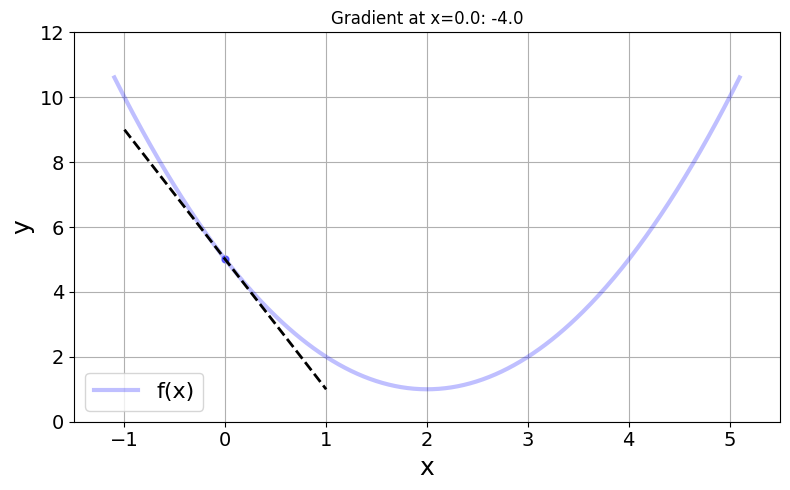

In [6]:
animate_gradient(f1, df1, x_start=-1, x_end=5, step=0.5, show_step=2)

As we already knew and now also see in th plot, the slope or gradient of $f(x)$ at $x=0$ is $-4$. This value contains two separate pieces of information that help us to find the value for $x$ that minimizes $f(x)$:

* **Sign:** The sign of the gradient tells us if we have a negative or positive gradient, i.e., whether the function is going down or up (when reading from left to right) &mdash; of course, if the gradient is $0$, we hit the minimum (or, in general, the maximum or saddle point). This means that if the gradient is, say, negative (like in our example $-4$), the gradient is going down, which means the minimum of $f(x)$ is further to the right. In other words, increasing $x$ from $0$ to, say, $0.1$ will give a smaller value for $f(x)$ &mdash; that is, we expect that $f(0.1) < f(0)$.

* **Absolute value:** The absolute value of the gradient represents the steepness of the slope. For example, our gradient of $g(x) = -4$ means that if we change $x$ by $1$ the value of $g(x)$ changes by $4$. This often gives us some idea how far away we are from the minimum of $f(x)$, but as we will see in a bit, the consideration of the absolute value can be rather complex in practice.

Based on these two observations, the basic idea behind Gradient Descent is as follows: We start with some initial value of $x$ and compute the gradient. The value of the gradient tells us if we should increase or decrease $x$ &mdash; and to some extent by how much &mdash; so that $x$ is now closer to the value that minimizes $f(x)$. Since this single change is likely to hit the minimum, we repeat this process of computing the gradient and modifying $x$ to get closer and closer to the minimum.

---

## The Gradient Descent Algorithm

The basic Gradient Descent algorithm is arguably a very simple algorithm as it implements the simple intuition we just outlined: start with some initial value for the variable of a function, such as $x$ for function $f(x)$, use the first derivative $g(x) = \frac{df(x)}{x}$ to compute the gradient, and update $x$ based on the gradient such that $x$ is closer to the minimum of $f(x)$.

In the following, we first consider the most basic case of univariate function, i.e., functions which only depend on a single input variable. We then generalize the idea of Gradient Descent to multivariate functions, i.e., functions that depend on more than one input variable.

**Note:** Throughout this section, we also make two simplifying assumptions. Firstly, as mentioned before, we limit ourselves to finding the minimum of a function &mdash; although Gradient Descent can be applied to find other critical points (maximums or saddle points). And secondly, we assume that the functions have only a single minimum &mdash; we assume all functions are **convex**. We later get rid of this assumption when talking about the challenges and limitations of the Gradient Descent algorithm.

### Univariate Functions

**Univariate functions** are functions that depend on only one input variable. For example, our initial function $f(x) = x^2 - 4x + 5$ is a univariate function as its output only depends on the value of $x$. So let's just continue to use this function for the following discussion. This includes that we also have the first derivative $g(x) = \frac{df(x)}{x}$ which allows us to compute the gradient of $f(x)$ for any value of $x$. With this, the Gradient Descent Algorithm breaks down into two main phases: the initialization and the iterative updates.


#### Initialization 

Since we cannot directly compute the value for $x$ that minimizes $f(x)$ Gradient Descent starts with "some" value for $x$, let's call it $x^{(0)}$, to later update $x$ to get closer to the minimum. In principle, using our assumption of convex functions, any initial choice for $x^{(0)}$ will work. And if we do now know anything about the function $f(x)$, a random choice or $x^{(0)}$ is typically the best we can do.

On the other hand, just looking at the previous plots, it seems intuitive that somehow picking a value for $x^{(0)}$ close to the minimum would be great as it would overall speed up the algorithm for finding the minimum. Making smarter choices for $x^{(0)}$ can be done if we have some understanding of $f(x)$ or what it aims to capture. For example, let's assume that we have a function $f(x)$ that estimates the average number of minutes a person sleeps per day depending on his or her age $x$. Since $x$ represents a person's age, it is arguably not meaningful to choose negative values for $x^{(0)}$ or values (way) above $100$. Moreover, expecting that working-age people sleep less than babies and elderly, choosing $x^{(0)}$ somewhere between $30$ and $40$ seems meaningful.

In the following, we do not assume any prior knowledge about $f(x)$, we basically set $x^{(0)}$ randomly. Again, this does not affect the underlying algorithm (assuming convex functions!) but "only" its efficiency, which is important in practice but beyond our scope here of covering the basics.

#### Iterative Updates

With the initial choice for $x^{(0)}$, we do not have the first value for $x$ for which we can compute the gradient using $g(x)$. Since it is arbitrarily unlikely the $x^{(0)}$ already marks the minimum of $f(x)$ by sheer luck, the gradient will be some positive or negative value. As we already saw, a negative value for $g(x)$ means that (slightly) increasing $x$ yields lower values for $f(x)$, which is exactly what we want. Vice versa, if $g(x)$ is positive, decreasing $x$ will bring us closer to the minimum. Thus, we can &mdashl or rather could &mdash; define the update rule for $x$ as follows:

$$\large
x^{(n)} = x^{(n-1)} - g(x^{(n-1)})
$$

where $x^{(n)}$ is the value of $x$ at the $n$-th update step, and $x^{(n-1)}$ is the value of $x$ at step $n-1$ starting from $x^{(0)}$. The minus sign ensures that we increase $x$ if the gradient is negative, and decrease $x$ if the gradient is positive. However, this simple update rule is generally unsuitable in practice. To illustrate this, let's again have a look at the gradient for $x=0$ with $g(x) = -4$ for our example function.

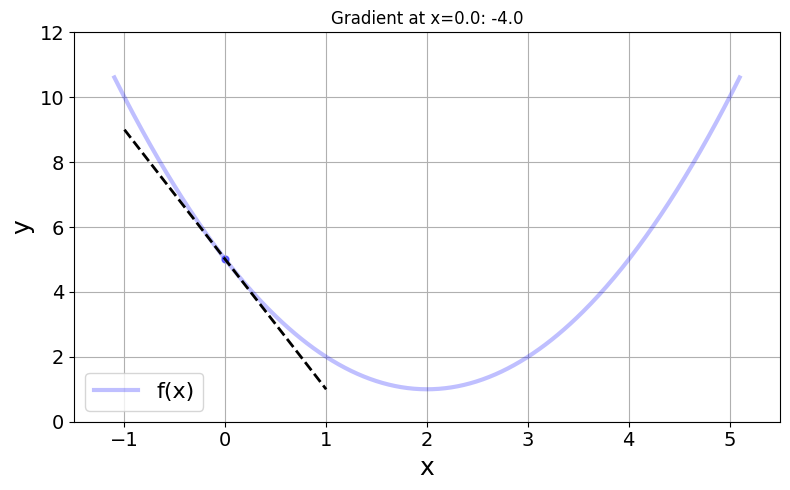

In [7]:
animate_gradient(f1, df1, x_start=-1, x_end=5, step=0.5, show_step=2)

Since here $x=0$ and $g(x) = -4$, the update rule would imply that we need to update $x$ from $0$ to $4$. Just by looking at the plot above, however, we can already tell that increasing $x$ by that much we would overshoot the minimum which is at $x=2$. Although overshooting in itself is not necessarily a problem &mdash; as we cover alter &mdash; the general observation is that the absolute gradient values are a poor indicator of how much we should update $x$. More specifically, the absolute gradient value is almost always too large to be used "as is" for the update rule.

As a consequence, we need some scaling factor &mdash; commonly denoted by $\eta$ &mdash; that reduces the gradient before updating $x$. The most commonly used and well-known term for $\eta$ is the **learning rate**. But again, despite the fancy name, the learning rate is just a scaling factor. By incorporating $\eta$, we get the final update rule for the Gradient Descent algorithm.

$$\large
x^{(n)} = x^{(n-1)} - \eta\cdot g(x^{(n-1)})
$$

Mathematically, assuming convex functions with a single minimum, Gradient Descent will "eventually" find the minimum, where "eventually" refers to an arbitrary number of applications of the update rule. In practice, however, we typically have some restrictions with respect of the number of update steps we can perform. This means that we more likely can only hope for a good estimate for the value $x$ that minimizes $f(x)$. Obviously, we generally aim for a good estimate, which depends on all three input parameters:

* **Initial value $x^{(0)}$:** The closer $x^{(0)}$ is to the true minimum, the less update steps are required

* **Learning rate $\eta$:** The learning rate $\eta$ determines by how much we scale the gradient and therefore by how much we update $x$ during the iterations. If we pick $eta$ too small, we only update $x$ a little bit in each iteration, thus requiring many steps to reach the minimum. In contrast, if we pick $\eta$ too large, we might overshoot the minimum potentially by so much that we end up further away from the minimum.

* **Number of update steps:** In general, particularly if we do not overshoot the minimum, the more update steps the better. But again, in practice, we try to minimize the number of steps or have some hard resource constraints.

To better illustrate what can happen during Gradient Descent depending on the choice of these three input parameters, we provide the function `animate_gradient_descent()` to show the progress of Gradient Descent for our example function $f(x) = x^2 - 4x + 5$. To keep it simple, and to highlight the importance of the learning rate $\eta$, let's assume we fix $x^{(0)} = -1$ and the number of update steps to $10$. Regarding the choice for learning rate $\eta$, we can distinguish the following cases using example values &mdash; and we recommend running the code cell below with these values:

* $\eta = 0.2$: When using $\eta=0.2$, each update changes $x$ "enough" that after $10$ steps $x$ is pretty close to the minimum. We can therefore say that $0.2$ is a good choice for the learning rate.

* $\eta = 0.02$: This much lower learning rate results in very small updates of $x$ in each iteration. While we still get closer and close to the minimum, we would need many more update steps to get reasonably close to the minimum.

* $\eta = 0.8:$ Using this learning rate, each update step overshoots the minimum. However since $f(x)$ still decreases, Gradient Descent still converges to the minimum only here by "jumping left to right".

* $\eta = 1.01:$ A learning rate larger than $1$ here not only causes the update step to overshoot the minimum but now also by so much that $f(x)$ increases. In this case, Gradient Descent will not converge to the minimum no matter the number of update steps; in fact, it will get worse and worse.

Given the simple nature of $f(x)$ there are also some other "special" values for the learning rate you can try. For example, with $\eta = 0.5$ the first update step will exactly hit the exact minimum. Also, with $\eta=1$, $f(x)$ will always be the same and the value of $x$ will flip between $-1$ and $5$.

In [8]:
animate_gradient_descent(f1, df1, x0=-1, eta=0.2, n_steps=10)

Apart from the image, the method `animate_gradient_descent()` also allows you to plot the result of the application of Gradient Descent as a static image by setting the `show_step` argument. To ensure that the plot shows all the steps, we only need to set `show_step` to the number of update steps `n_steps`.

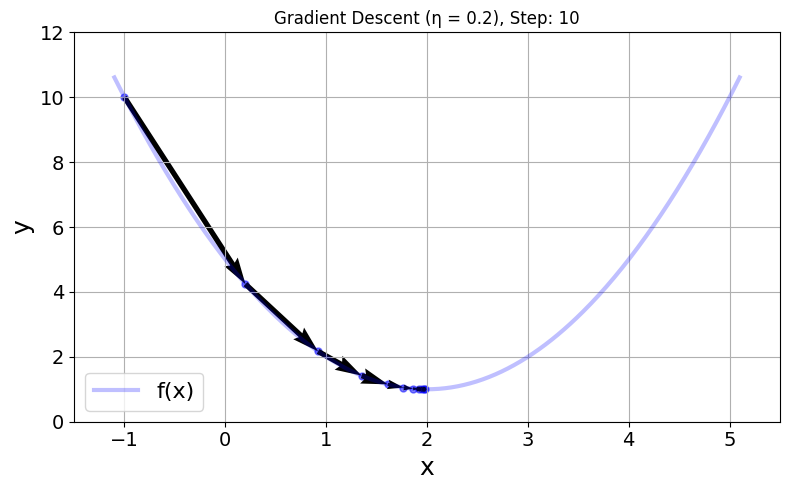

In [9]:
n_steps = 10

animate_gradient_descent(f1, df1, x0=-1, eta=0.2, n_steps=n_steps, show_step=n_steps)

As a summary and for a direct comparison, the figure below shows the plots for all four outlined example values for the learning rate $\eta$.

<img src="../common/images/plots/gd/gd-learning-rate-comparison.png">

**Important:** The values for the learning rate $\eta$ and their effects on the Gradient Descent algorithm in terms of finding a good estimate for the minimum naturally highly depends on the function $f(x)$ and its first derivative. In other words, a value for $\eta$ which we would consider a "good learning rate" (e.g., $\eta=0.2$ for our example function) will generally vary greatly depending on $f(x)$. Furthermore, particularly for multivariate functions (see below), we typically not simply plot and eye-ball the function to easily identify meaningful values for $\eta$ (as well as for $x^{(0)}$ and the number of update steps). Finding a good learning rate is therefore often very challenging in practice; again, we discuss this in more detail later. Just keep in mind that we worked so far with a very simple function $f(x)$ for illustrative purposes.

### Multivariate Functions

As the name suggests, a **multivariate function** is a function that depends on more than one input variable. While a multivariate function may depend on an arbitrary number of input variables $x_1, x_2, \dots, x_n$, in the following, we limited ourselves to just two variables as it does not affect the overall idea and we can still plot this functions. More specifically, let's consider the following multivariate function $f(x_1, x_2)$:

$$\large
f(x_1, x_2) = 0.2x_1^2 + x_2^2
$$

Just by looking at this function, it is easy to see that this function has its minimum at $x_1 = x_2 = 0$. Of course, we will go through the steps to get there using Gradient Descent. But before that, let's plot the function to see how it looks. For that, we first define a Python method `f2()` implementing this function.

In [10]:
def f2(x1, x2):
    return 0.2*(x1**2) + (x2**2)

We provide another auxiliary method `plot_multivariate_function()` to plot the function $f(x_1, x_2)$.

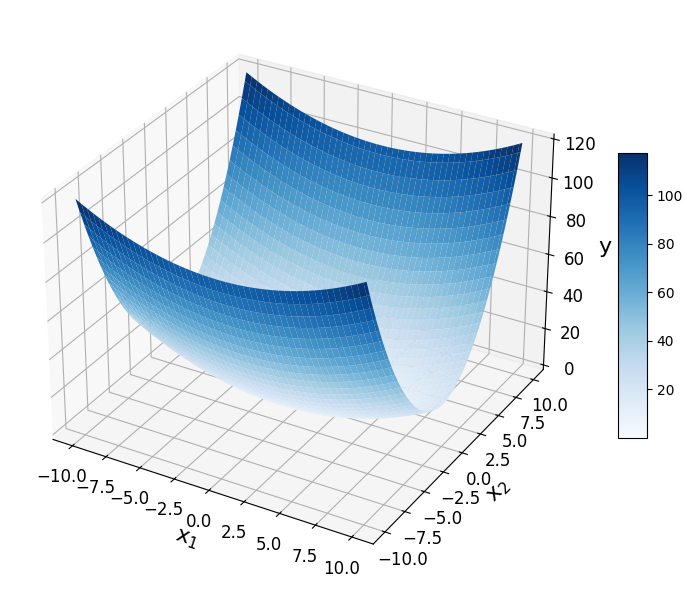

In [11]:
plot_multivariate_function(f2)

As you can see &mdash; and this should not come as a surprise given the simple function definition, $f(x_1, x_2)$ is again a convex function and has therefore a single global minimum. This means this function adheres to our assumption we have made so far.

When moving from a univariate function $f(x)$ to a multivariate function $f(x_1, x_2, \dots, x_n)$, the idea of a derivative generalizes in a natural way. In one dimension, the derivative tells us how the function changes when we slightly change $x$. In multiple dimensions, we can change each input variable independently, so we introduce **partial derivatives**. The partial derivative $(\frac{\partial f}{\partial x_i}$ measures how $f$ changes when only $x_i$ is varied while all other variables are held fixed. Together, these partial derivatives capture how sensitive the function is to each of its inputs. All partial derivatives can be collected into a single object called the **gradient**:

$$\large
\nabla f = \left(\frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2}, \dots, \frac{\partial f}{\partial x_n}\right)
$$

Notice that in the case of partial derivatives we commonly use $\partial f$ instead of $df$.

Unlike the derivative in one dimension, which is just a number (a scalar), the gradient is a **vector**. This vector points in the direction of the steepest increase of the function, and its magnitude tells us how steep that increase is. As such, the basic idea of using the gradient to update the variables $x_1, x_2, \dots, x_n$ to find the minimum remains the same. To better illustrate this, let's compute the two partial derivatives $\frac{\partial f}{\partial x_1}$ and$\frac{\partial f}{\partial x_2}$ for our example function using basic calculus rules.

$$
\begin{align}
\large \frac{\partial f}{dx_1}\ &\large= 0.4 x_1\\[0.5em]
\large \frac{\partial f}{dx_2}\ &\large= 2 x_2
\end{align}
$$

To compute an example gradient, we consider $x_1 = 9$ and $x_2 = -3$. After plugging in both value into the partial derivatives, we get the following gradient vector:

$$\large
\nabla f = \left(\frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2}\right) = \left(3.6, -6\right)
$$

The interpretation of the gradient is the same as for the univariate case just individually for each variable: Since $\frac{\partial f}{dx_1} = 3.6$ is positive, slightly decreasing $x_1$ will lower the value of $f(x_1, x_2)$. In contrast, $\frac{\partial f}{dx_2} = -6$ is negative, so we want to slightly increase the value of $x_2$ to find the minimum of our function. Fundamentally, the Gradient Descent algorithm is exactly the same: After initializing our two variables with $x_1^{(0)} and x_2^{(0)}, we iteratively update both variables now using to update rules.

$$
\begin{align}
\large x_1^{(n)}\ &\large= x_1^{(n-1)} - \eta\cdot g_1(x_1^{(n-1)})\\[1em]
\large x_2^{(n)}\ &\large= x_2^{(n-1)} - \eta\cdot g_2(x_2^{(n-1)})
\end{align}
$$

where $g_1$ and $g_2$ denote the partial derivatives $\frac{\partial f}{\partial x_1}$ and$\frac{\partial f}{\partial x_2}$, respectively. In principle, we can have different learning rates for the different update rules. However, the basic Gradient Descent algorithm cannot meaningfully distinguish between both variables to allow for "personalized" learning rates for each update rule.

To visualize the process, we first need to define a method computing the gradient for our function. Notice that the method `df2` in the code cell below now returns $2$ values reflecting the $2$ partial derivatives.

In [12]:
def df2(x1, x2):
    return 0.4*x1, 2*x2

For the visualization, we provide the method `plot_gradient_descent_multivariate()` the plots a contour plot that draws curves along which the function $f(x_1, x_2)$ has the same value. Each contour line represents a fixed "height" of the surface $y = f(x_1,x_2)$, similar to how a topographic map shows lines of equal elevation. Where contour lines are close together the function changes rapidly (steep regions), and where they are far apart the surface is flatter. As for the example above, initialize the Gradient Descent algorithm with consider $x_1^{(0)} = 9$ and $x_2^{(0)} = -3$, and use a learning rate $\eta=0.2$ &mdash; but you are encouraged to modify those values to see their effects on the results.

In [13]:
plot_gradient_descent_multivariate(f2, df2, x0=(9, -3), eta=0.2, n_steps=100)

Notice that the number of update steps is much higher compared to our univariate function. This is because our multivariate function $f(x_1, x_2)$ is rather "flat" near the minimum. This means that the gradients and therefore the changes to $x_1$ and $x_2$ after each update will be very small. This is a general practical challenge of the Gradient Descent algorithm, and we cover it in more detail in the subsequent section.

As before, instead of an animation, we can also visualize the result as a static plot by setting the `show_step` argument of the auxiliary method.

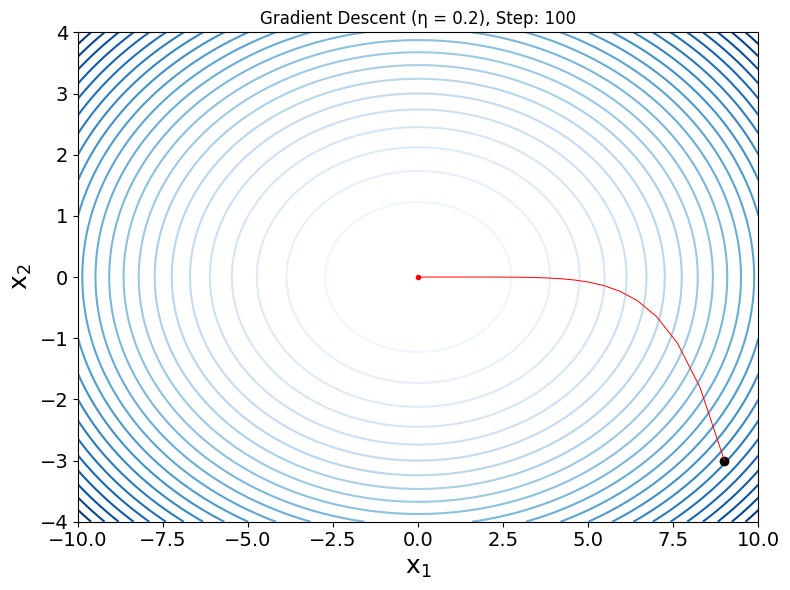

In [14]:
n_steps = 100

plot_gradient_descent_multivariate(f2, df2, x0=(9, -3), eta=0.2, n_steps=n_steps, show_step=n_steps)

In short, gradient descent for a multivariate function works exactly the same way as for a univariate one: you repeatedly move in the direction that most decreases the function value. In one dimension this direction is given by the derivative, while in multiple dimensions it is given by the gradient. The guiding principle does not change (i.e., follow the slope downhill) but the object that describes the slope becomes richer. The increased complexity comes from having to deal with **partial derivatives** and **vectors** instead of a single derivative. Instead of one number telling you how to move left or right, the gradient provides a whole vector that tells you how to adjust every input variable simultaneously. Apart from this added bookkeeping and geometry, the idea of iteratively stepping toward lower values of the function remains fundamentally the same.

---

## Discussion: Limitations & Challenges

### Fundamental Challenges

Most obviously, although not explicitly stated so far, the Gradient Descent algorithm relies on (partial) derivatives. This, in turn, assumes that the function $f$ is differentiable because the gradient is what tells us the direction of steepest decrease. If a function is not differentiable at a point, the gradient is undefined there, so there is no clear "best direction" to move in. Without differentiability, the method loses the local slope information it needs to decide how to update the variables, making its basic update rule mathematically ill-defined.

We also already highlighted that the algorithm, both in terms of effectiveness in converging to the minimum as well in terms of its efficiency, is rather sensitive to the choice for the learning rate $\eta$. However, Gradient Descent poses additional challenges that we so far only touched upon on using side comments. So let's look at those fundamental challenges a bit more closely.

#### Non-Convex Functions

Recall that we have so far assumed that the function $f$ is convex. A **convex function** is one whose graph always lies below the straight line connecting any two of its points. Intuitively, this means the function has a single bowl-shaped surface with no dips or bumps. A key consequence is that any local minimum is also the global minimum, which makes optimization much easier because Gradient Descent cannot get trapped in bad local minima. To give an example, consider the following function:

$$\large
f(x) = x\cos{x} + 9
$$

and let's define this function as a Python method and plot it for a small range of $x$ values.

In [15]:
def f_nonconvex(x):
    return x * np.cos(x) + 9    

Clearly, this function is no longer convex, and just for the limited range for $x$, this function has $3$ local minima. However, this function is differentiable which means that we can compute the derivative and the gradients to perform Gradient Descent. Using the product rule of calculus and the derivatives of trigonometric functions, we get the following derivative of $f(x)$:

$$\large
\frac{df}{dx} = \cos{x} - x\sin{x}
$$

Like before, we first implement this function as a Python method for later use.

In [16]:
def df_nonconvex(x):
    return np.cos(x) - x*np.sin(x)

With the derivative, we can again try to find the minimum of $f(x)$ using Gradient Descent &mdash; the update rule is exactly the same, only the derivative to compute the gradient is different. Using the auxiliary method `animate_gradient_descent_nonconvex()` we can visualize the iterative updates to see how the algorithm updates $x$ to get closer to the minimum. Now, however, our function is non-convex and there are multiple minima. This means that the minimum the Gradient Descent algorithm will converge depends on the choice of $x_0$, but strictly speaking on the learning rate $\eta$. Run the code cell below with different values for $x^{(0)}$ and $\eta$ and see how the algorithm behaves, i.e., which minimum the algorithm converges to.

In [17]:
animate_gradient_descent_nonconvex(f_nonconvex, df_nonconvex, x0=12, eta=0.1, n_steps=10)

Like before, this auxiliary method supports to create static plots instead of animation to quickly see the final result the algorithm for different values of $x^{(0)}$ and $\eta$.

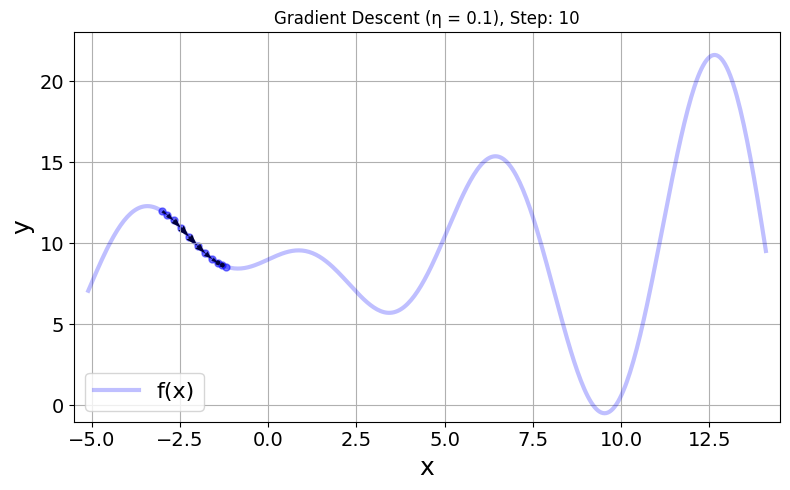

In [18]:
n_steps = 10

animate_gradient_descent_nonconvex(f_nonconvex, df_nonconvex, x0=-3, eta=0.1, n_steps=n_steps, show_step=n_steps)

The overall observation is that, assuming a "good" learning rate $\eta$, the algorithm only finds the global minimum if we pick $x^{(0)}$ somewhere between $7$ and $12$. Of course, if we use a very large learning rate, we might actually jump out of the "valley" of the global minimum.

Getting stuck in a local minimum in case of non-convex function is a fundamental challenge when it comes to using Gradient Descent to find the global minimum of a function; particularly when we cannot simply plot the function and easily spot a good choice for $x^{(0)}$. And in some sense, this cannot be solved as there is no guaranteed way to always find the global minimum. However, there are common strategies to improve the chances.

* **Multiple random starting points:** Once $x^{(0)}$ has been chosen, Gradient Descent is a deterministic algorithm. The idea is therefore to run the algorithm multiple times with different initial starting points $x^{(0)}$ and pick the smallest value across all runs for the minimum.

* **Noisy updates:** This approach adds some randomness to the algorithm by add some noise to the update rule:
$$\large
x^{(n)} = x^{(n-1)} - \eta\cdot g(x^{(n-1)}) + noise
$$
The intuition is that local minima are often small and shallow, and the global minimum is more pronounced. With this assumption, add some noise to the update rule can help the update rule to "skip" or "jump out" of these small local minima without much affect the convergence to the global minimum

* **Learning rate schedules:** So far, we assumed that the learning rate $\eta$ is fixed throughout all iterations of the algorithm. However, there is no reason why the learning cannot be different across iterations, i.e., between the applications of the update rule(s). For example, a common strategy is to start with a relatively large learning rate and then gradually decrease it. Large steps help escape poor minima early; small steps help refine the solution later. More sophisticated strategies might periodically swing between larger and smaller learning rates.

* **Momentum-based methods:** In basic Gradient Descent, each update step only depends on the current gradient. In contrast, momentum-based methods also keep information about past gradients and update steps. The intuition is that if we went $10$ steps into the same direction, then we will most likely go into the same direction in Step 11 as well...so why not make a bigger step since we can be fairly sure that we are going in the right direction. Again, this can help to jump over small local minima, but also speed up the algorithm overall.

In short, Gradient Descent is fundamentally local, so escaping local minima relies on giving it enough freedom to explore the landscape before settling down, i.e., converging to a minimum which is hopefully the global minimum. Particularly learning rate schedules and momentum based methods are very commonly used when training machine learning models using Gradient Descent or related methods. However, a deeper discussion is the topic of other notebooks and beyond the scope of this basic introduction to Gradient Descent.

#### Scaling and Conditioning

The issue of scaling and conditioning arise for multivariate functions where we have multiple input variables and therefore multiple partial derivatives. To see this in action, let's have another look at our function $f(x_1, x_2)$ and plot a single run of the Gradient Descent algorithm.

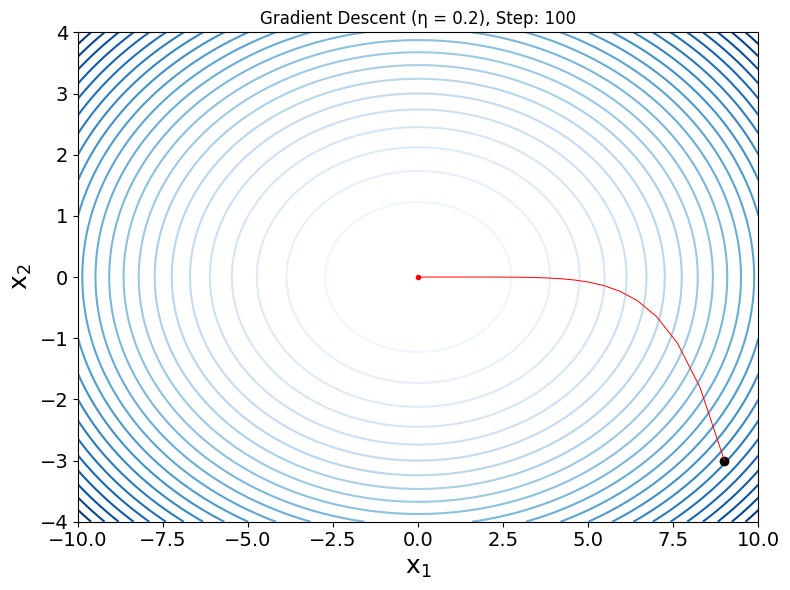

In [19]:
n_steps = 100

plot_gradient_descent_multivariate(f2, df2, x0=(9, -3), eta=0.2, n_steps=n_steps, show_step=n_steps)

You notice the path the iterative updates describe are not a straight line from the start (black dot) to the minimum at $(0, 0)$. This is because two gradients for the two variables are quite different. More specifically, the gradient for $x_2$ is much larger than the one for $x_2$. Recall, that these are the two partial derivatives:

$$
\begin{align}
\large \frac{\partial f}{dx_1}\ &\large= 0.4 x_1\\[0.5em]
\large \frac{\partial f}{dx_2}\ &\large= 2 x_2
\end{align}
$$

Since both update rules use the same learning rate, the change in $x_2$ is likely to be larger than the change in $x_1$. And in our example, the difference with respect to the two partial derivatives is not even that large. A common result in practice is the so-called "Zig-Zag" effect, where we choose a learning rate $\eta$ that is alright from some direction but too high for other directions. Again, we can visualize this by running Gradient Descent before but with a higher learning rate.

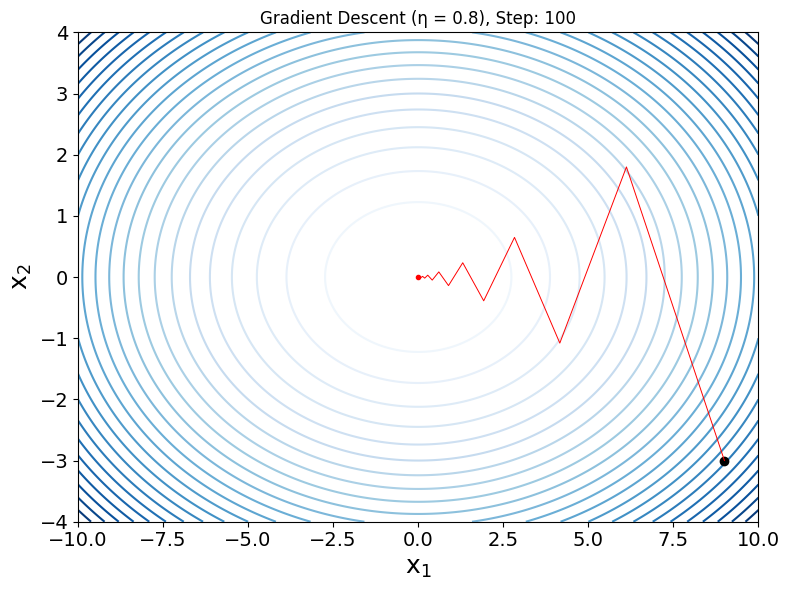

In [20]:
n_steps = 100

plot_gradient_descent_multivariate(f2, df2, x0=(9, -3), eta=0.8, n_steps=n_steps, show_step=n_steps)

Note that this example does not necessarily show a bad thing. After all, we actually reach the minimum faster with $\eta=0.8$ than $\eta=0.2$ here. However, it does highlight once again the algorithm's sensitivity to the choice of the learning rate, particularly for multivariate functions.

A common approach trying to address these issues are **second-order methods** which not only looks at "which way is downhill" (the gradient) but also "how steep or flat the surface is in each direction". They use information about the curvature of the function, captured by the Hessian matrix (second derivatives), to understand whether a direction is a steep wall or a gentle slope. Instead of taking the same-sized step in every direction, the algorithm automatically takes **smaller steps in steep directions and larger steps in flat ones**, reshaping the space so the landscape looks more like a round bowl than a long, narrow valley. In simple terms, this means we no longer zig-zag across narrow valleys but "rescale" the problem so that moving toward the minimum is well balanced in all directions, allowing it to move almost straight toward the solution.

However, in practice, full second-order methods are not used to train large neural networks because they are far too expensive. Computing and storing the Hessian matrix requires memory and time that scales with the square of the number of parameters, and modern networks can have millions or billions of weights. Even just inverting or solving linear systems with the Hessian is computationally infeasible at that scale and simply not practical for deep learning. However, the idea behind second-order methods is still very influential. Optimizers like **Adam, RMSProp, and Adagrad** can be seen as cheap approximations that adapt the learning rate for each parameter based on past gradients, partially mimicking curvature information. But again, a more detailed discussion is beyond our scope here.

### Gradient Descent for Model Training

Although we (partially) motivated the topic of Gradient Descent as a means to train machine learning models, we saw that the Gradient Descent algorithm is a general optimization method to iteratively find the critical points of a function. However, the functions we have considered so far were not proper loss functions. While the basic idea and the core algorithm of Gradient Descent does not change, loss function for machine learning adds additional considerations and complexity. In the following, we will briefly outline those challenges.

Recall that in supervised machine learning, we want to build models that make predictions close to the true values with respect to the training data. During the training, each training sample gives us two value:

* $y_{i}$: the $true$ value of the dependent or output variable of the $i$-th training sample

* $\hat{y}_{i}$: the $estimated$ or $predicted$ value as output of the model for the $i$-th training sample

Naturally, we prefer that $y_{i}$ and $\hat{y}_{i}$ are very similar for all training samples. To quantify the similarity or difference, we define a loss function. Thus, in simple terms, the loss for the $i$-th data sample is defined as:

$$\large
\mathcal{L}(\hat{y}_i, y_i) = \text{"difference between estimates/predictions and true values for the i-th training sample"}
$$

If we stick with regression tasks here, the true value $y_i$ is just a numerical value. In contrast, the estimated value $\hat{y}_i$ is the model output &mdash; that is, crudely speaking, the output of "some" function. For a concrete example, let's assume a Linear Regression model with two input features; thus, $\hat{y}_i$ is defined as

$$\large
\hat{y}_i = w_{0} + w_{1}x_{i1} + w_{2}x_{i2}
$$

where $x_{i1}$ and $x_{i2}$ are the values for the two features for the $i$-th training sample; $w_1$ and $w_2$ are the two coefficients for both features values, and $w_0$ is the bias term. We use the common notation $w$ for "weight". Now that we know what $\hat{y}_i$ and $y_i$, we now need the actual loss function. The most commonly used loss function for Linear Regression is the Mean Squared Error (MSE) loss, which is defined as:

$$\large
\mathcal{L}(\hat{y}_i, y_i) = (\hat{y}_i - y_i)^2
$$

Plugging in the expression for $\hat{y}_i$, we get:

$$\large
\mathcal{L}(\hat{y}_i, y_i) = (w_{0} + w_{1}x_{i1} + w_{2}x_{i2} - y_i)^2
$$

This means that the loss is a function that depends on true value and the feature values for the $i$-th training sample, as well as the weights $w_j$. We can make this more explicit by write the loss function as $\mathcal{L}(y_i; \mathbf{x}_i, \mathbf{w})$ where $\mathbf{w}_i$ represents the vector of all weights $w_0, w_1, \dots, w_d$ (with $d=2$ in our example), and $\mathbf{x}_i$ represents the vector of feature values for the $i$-th training sample. Note that $\mathbf{x}_i$ contains the "artificial feature" $x_{i0} = 1$ for the bias term so that vectors $\mathbf{w}$ and $\mathbf{x}_i$ have the same size.

Of course, minimizing the loss for a single training sample is trivial. All we need to do is set $w_0 = y_i$ and $w_1 = w_2 = 0$. The "problem" is that we have many training samples, each with its own values for $x_{ij}$ and $y_i$, and we want to minimize the loss for all training samples. This the MSE loss with respect to list of training samples is the average of the individual losses for each sample:

$$
\begin{align}
\large \mathcal{L}(\mathbf{y}; \mathbf{X}, \mathbf{w})\ &\large= \frac{1}{n}\sum_i^n (\hat{y}_i - y_i)^2\\[1em]
&\large= \frac{1}{n}\sum_i^n (w_{0} + w_{1}x_{i1} + w_{2}x_{i2} - y_i)^2
\end{align}
$$

where $\mathbf{X} \in \mathbb{R}^{n\times d}$ is the data matrix containing the $n$ training samples, each with $d$ features, and $\mathbf{y}\in \mathbb{R^n}$ is the vector containing the $n$ true values for each training sample. Training a Logistic Regression model now means minimizing this function $\mathcal{L}(\mathbf{y}; \mathbf{X}, \mathbf{w})$. Although the MSE loss function for Linear Regression is simple enough so it can be solved analytically, let's assume we want to use the Gradient Descent algorithm.

Note that in this notation $x_{ij}$ are now feature values from the training data which we cannot update. To minimize the loss function, we want to find the weights $w_i$ that minimize $\mathcal{L}$, which in term means that we have to compute all partial derivatives

$$\large
\frac{\partial \mathcal{L}}{\partial w_0},\ \frac{\partial \mathcal{L}}{\partial w_1},\ \frac{\partial \mathcal{L}}{\partial w_2},\ \dots,\ \frac{\partial \mathcal{L}}{\partial w_d}
$$

Here, we actually do not care about the partial derivatives, but if you are interested, we go through all the math in full detail in the notebooks covering Linear Regressions. Once we have the partial derivatives, however, the Gradient Descent algorithm works exactly the same. Since we have $d$ variables, the algorithm will have $d$ update rules (as we saw for multivariate functions before).

Alhough we minimize $\mathcal{L}(\mathbf{y}; \mathbf{X}, \mathbf{w})$ with respect to all weights $w_i$, the value for the loss obviously still depends on the training data captured by the data matrix $\mathbf{X}$. The training naturally considers all the training samples, but we have a choice when and how often we want to compute the gradients and update the weights. There are generally three basic approaches:

* **Batch Gradient Descent** uses the complete training data to compute the gradients and update the weights.

* **Mini-Batch Gradient Descent** splits the training data into smaller batches of training samples and computes the gradients and updates the with respect to each batch

* **Stochastic Gradient Descent** computes the gradients and updates the weights for each individual training sample in the dataset.

All three approaches have their pros and cons, but their detailed discussion is the subject of its own notebook. The important observation is that the update of the weights depend on the subsets (e.g., batches) of training samples used to compute the gradients. In other words, two different batches will generally yield different weight updates. While this additional consideration does not affect the actual Gradient Descent algorithm, it typically affects the rate of convergence and the choice of a good learning rate $\eta$. But again, these topics will be covered in a separate notebook.

---

## Summary

Gradient Descent is an iterative optimization algorithm used to find **critical points** of a function, i.e., points where the gradient (the vector of partial derivatives) is zero or close to zero. In practice, these are candidates for minima, maxima, or saddle points, and in optimization we are usually interested in finding a minimum. The basic idea is simple: starting from an initial guess, we repeatedly move in the direction that locally decreases the function the most. This direction is given by the **negative gradient**, because the gradient points in the direction of steepest increase.

At each iteration, Gradient Descent updates the current position by taking a small step opposite to the gradient, scaled by a parameter called the **learning rate**. If the learning rate is too large, the algorithm may overshoot and diverge; if it is too small, convergence becomes very slow. Over many iterations, this process traces out a path through the input space, ideally settling into a region where the gradient is close to zero, meaning the function cannot be reduced much further by small local moves.

Although the idea can be illustrated easily in one dimension, Gradient Descent is most powerful in **high-dimensional settings**, where a function depends on many variables. In these cases, solving for critical points analytically is often impossible, but computing gradients is still feasible. The algorithm naturally generalizes by using the gradient vector, which tells us how to adjust all variables at once in a way that locally reduces the function value.

This makes Gradient Descent central to **machine learning**, where training a model means minimizing a loss function that measures how wrong the model’s predictions are. Neural networks, for example, may have millions of parameters, but Gradient Descent (together with backpropagation) allows us to compute how each parameter should change to reduce the overall error. Variants such as stochastic gradient descent, momentum, and adaptive methods are all built on this same core idea of iteratively following the negative gradient.